In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.getcwd())

import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["TeX Gyre Pagella", "Book Antiqua", "Palatino Linotype", "DejaVu Serif"]
})

import pickle
import jax
import jax.numpy as jnp

from conditional_diffusion_3d_model import ConditionalUNet3D, DiffusionModelConfig
from train_conditional_diffusion import preload_hdf5_to_memory, train_model

### Import validation data

In [2]:
val_path = "/projects/mccleary_group/habjan.e/TNG/Data/conditional_diffusion_data/cond_diffusion_vdisp_test.h5"
data_dict = preload_hdf5_to_memory(val_path)


Preloading /projects/mccleary_group/habjan.e/TNG/Data/conditional_diffusion_data/cond_diffusion_vdisp_test.h5 into memory...
✓ Loaded 1000 samples in 8.19s (1.13 GB)


### Import samples

In [3]:
suffix = '_64cube_v4'
#sample_base_path = '/projects/mccleary_group/habjan.e/TNG/Data/conditional_diffusion_data/cd_samples/'
#sample_path = sample_base_path + f'sampled_cubes_validx_0000{suffix}.npz'

sample_base_path = '/projects/mccleary_group/habjan.e/TNG/Data/conditional_diffusion_data/cd_examples_times/'
sample_path = sample_base_path + f'sampled_cubes_validx_0002{suffix}_respaced_multistep.npz'
data = np.load(sample_path)
data_im, data_true_cube, data_sampled_cubes, seeds, inf_steps = data['conditioning_images'], data['true_cube'], data['sampled_cubes'], data['seeds'], data['num_inference_steps']

### Plot data

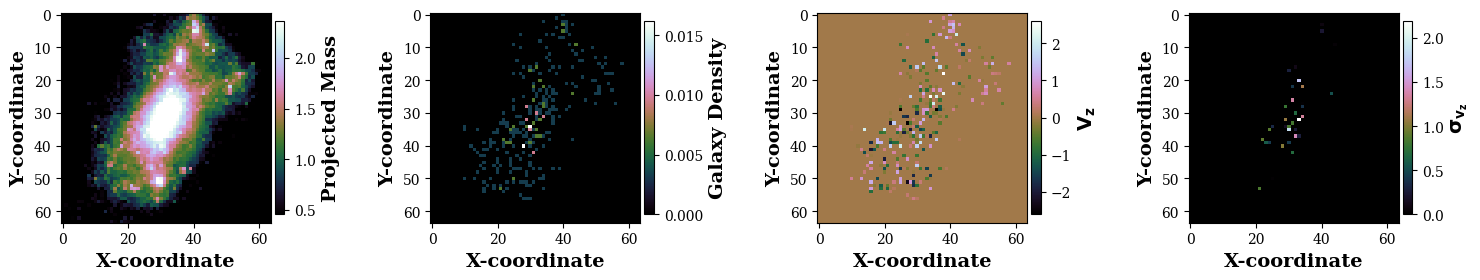

In [4]:
#imgs = data_dict['images'][7]
imgs = data_im
cmap = 'cubehelix'

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 10), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.2, h_pad=0.2, wspace=0.1, hspace=0.1)
ax1, ax2, ax3, ax4 = axes[0], axes[1], axes[2], axes[3]
#ax1, ax2, ax3 = axes[0], axes[1], axes[2]

im1 = ax1.imshow(imgs[0], vmin = np.quantile(imgs[0], 0.5), vmax = np.quantile(imgs[0], 0.98), cmap=cmap, origin="upper")
ax1.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax1.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
cbar = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

im2 = ax2.imshow(imgs[1], cmap=cmap, origin="upper")
ax2.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax2.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label("Galaxy Density", fontsize=14, fontweight='semibold')

im3 = ax3.imshow(imgs[2], cmap=cmap, origin="upper")
ax3.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax3.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
cbar = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.02)
cbar.set_label("$\mathbf{V_{z}}$", fontsize=14, fontweight='semibold')

im4 = ax4.imshow(imgs[3], cmap=cmap, origin="upper")
ax4.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax4.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
cbar = fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.02)
cbar.set_label("$\mathbf{\sigma_{v_z}}$", fontsize=14, fontweight='semibold')

#fig.savefig("/home/habjan.e/TNG/cluster_deprojection/figures/cnnmlp_data.png", bbox_inches="tight")
plt.show()

### Projected true density cube in zx-plane

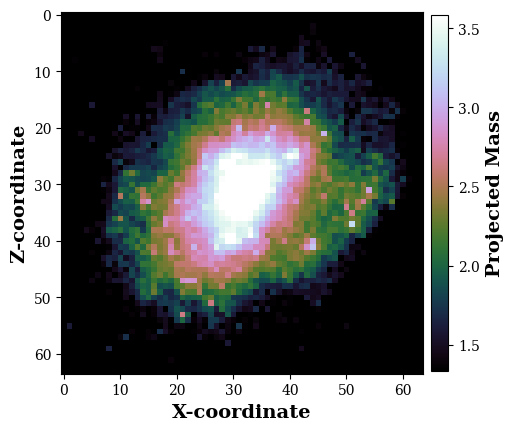

In [79]:
cube_mean = data_dict["metadata"]["cube_log10_mean"]
cube_std  = data_dict["metadata"]["cube_log10_std"]

log10_rho = data_true_cube * cube_std + cube_mean
rho = 10**log10_rho

rho_im = np.sum(rho, axis = 1)

imgs = (np.log10(rho_im ) - data_dict["metadata"]["proj_mass_log10_mean"]) / data_dict["metadata"]["proj_mass_log10_std"]
cmap = 'cubehelix'

fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), constrained_layout=False)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.2, wspace=-0.1, hspace=0.1)

im1 = ax1.imshow(imgs, vmin = np.quantile(imgs, 0.5), vmax = np.quantile(imgs, 0.98), cmap=cmap, origin="upper")
ax1.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax1.set_ylabel("Z-coordinate", fontsize=14, fontweight='semibold')
cbar = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

### Project the density cube - it should look just like the projected cube above

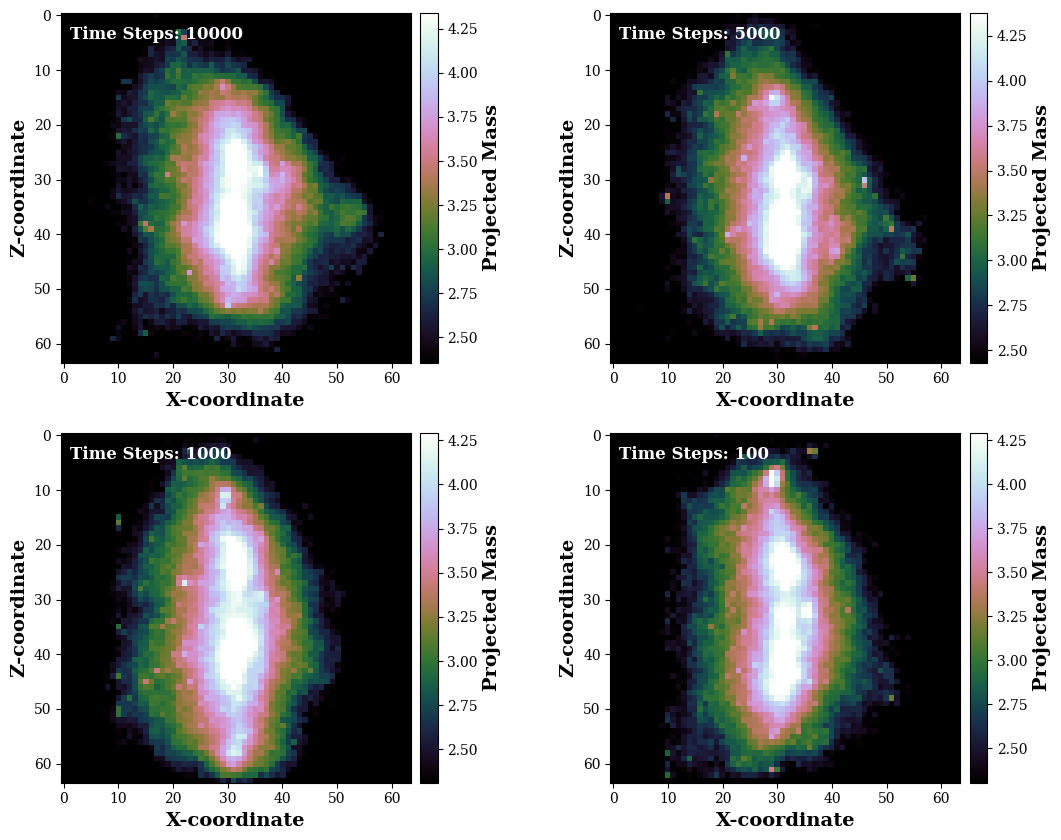

In [80]:
cube_mean = data_dict["metadata"]["cube_log10_mean"]
cube_std  = data_dict["metadata"]["cube_log10_std"]

#log10_rho = data_sampled_cubes * cube_std + cube_mean
log10_rho = data_sampled_cubes[:, 0] * cube_std + cube_mean
rho_samp = 10**log10_rho

rho_im = np.sum(rho_samp, axis = 2)

samp_imgs = (np.log10(rho_im ) - data_dict["metadata"]["proj_mass_log10_mean"]) / data_dict["metadata"]["proj_mass_log10_std"]
cmap = 'cubehelix'
fs = 12

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 10), constrained_layout=False)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.2, wspace=-0.1, hspace=0.1)
ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

ind = 0
im1 = ax1.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax1.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax1.set_ylabel("Z-coordinate", fontsize=14, fontweight='semibold')
ax1.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax1.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

ind = 1
im2 = ax2.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax2.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax2.set_ylabel("Z-coordinate", fontsize=14, fontweight='semibold')
ax2.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax2.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

ind = 2
im3 = ax3.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax3.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax3.set_ylabel("Z-coordinate", fontsize=14, fontweight='semibold')
ax3.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax3.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

ind = 4
im4 = ax4.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax4.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax4.set_ylabel("Z-coordinate", fontsize=14, fontweight='semibold')
ax4.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax4.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

### Projected cubes in xy-plane

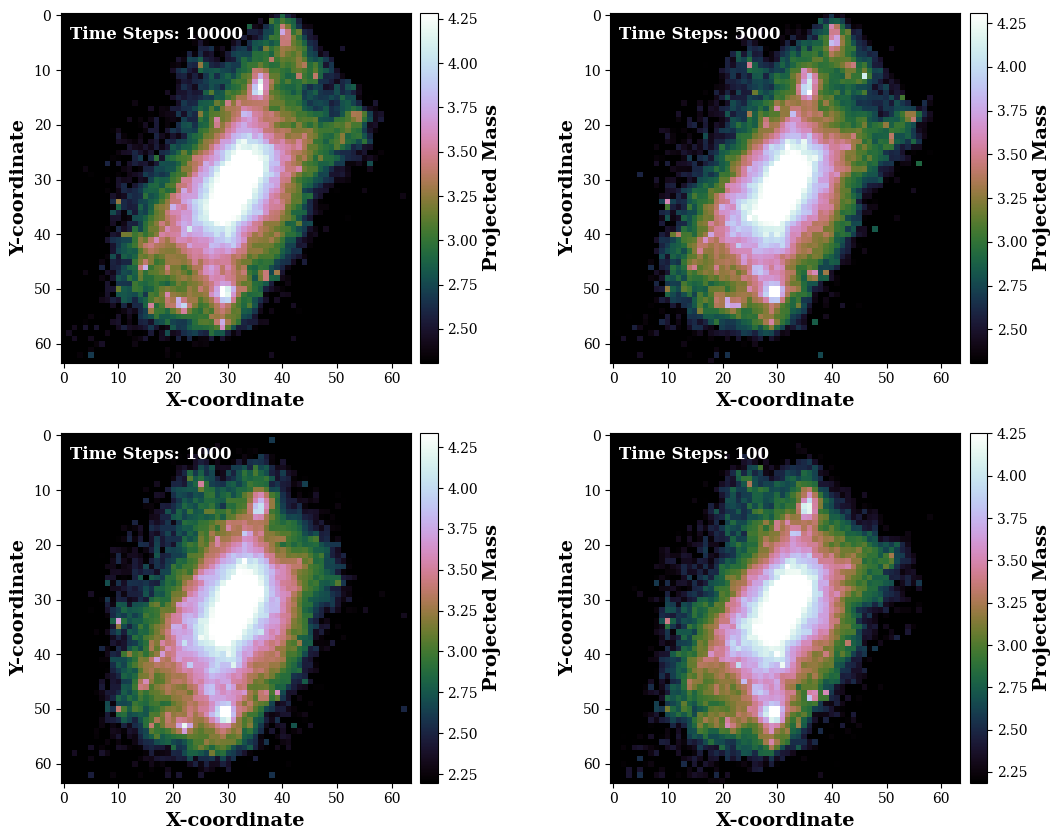

In [81]:
cube_mean = data_dict["metadata"]["cube_log10_mean"]
cube_std  = data_dict["metadata"]["cube_log10_std"]

#log10_rho = data_sampled_cubes * cube_std + cube_mean
log10_rho = data_sampled_cubes[:, 0] * cube_std + cube_mean
rho_samp = 10**log10_rho

rho_im = np.sum(rho_samp, axis = 1)

samp_imgs = (np.log10(rho_im ) - data_dict["metadata"]["proj_mass_log10_mean"]) / data_dict["metadata"]["proj_mass_log10_std"]
cmap = 'cubehelix'
fs = 12

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 10), constrained_layout=False)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.2, wspace=-0.1, hspace=0.1)
ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

ind = 0
im1 = ax1.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax1.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax1.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
ax1.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax1.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

ind = 1
im2 = ax2.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax2.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax2.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
ax2.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax2.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

ind = 2
im3 = ax3.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax3.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax3.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
ax3.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax3.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

ind = 4
im4 = ax4.imshow(samp_imgs[ind], vmin = np.quantile(samp_imgs[ind], 0.5), vmax = np.quantile(samp_imgs[ind], 0.98), cmap=cmap, origin="upper")
ax4.set_xlabel("X-coordinate", fontsize=14, fontweight='semibold')
ax4.set_ylabel("Y-coordinate", fontsize=14, fontweight='semibold')
ax4.text(0.025, 0.925, f'Time Steps: {inf_steps[ind]}', transform=ax4.transAxes, color='white', weight='semibold', size=fs)
cbar = fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.02)
cbar.set_label("Projected Mass", fontsize=14, fontweight='semibold')

### Look at coorelation between different density maps

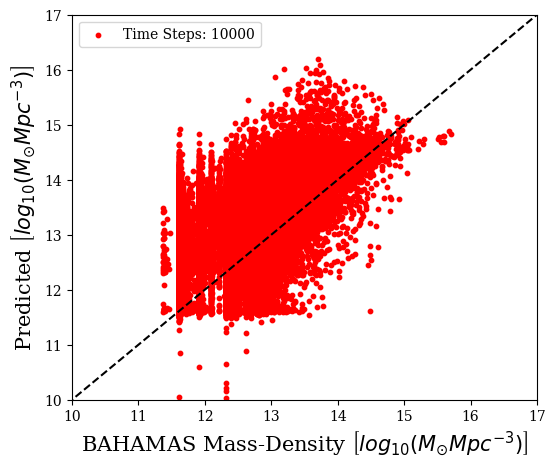

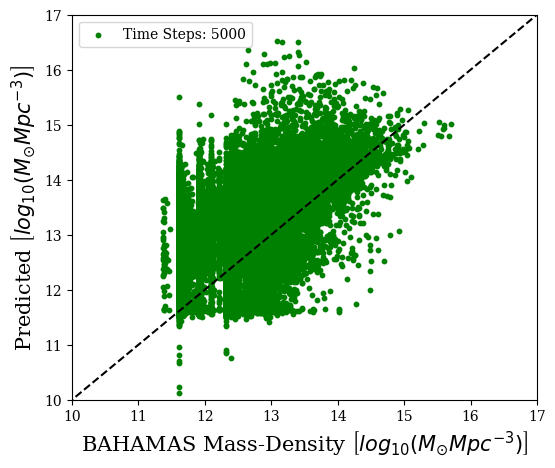

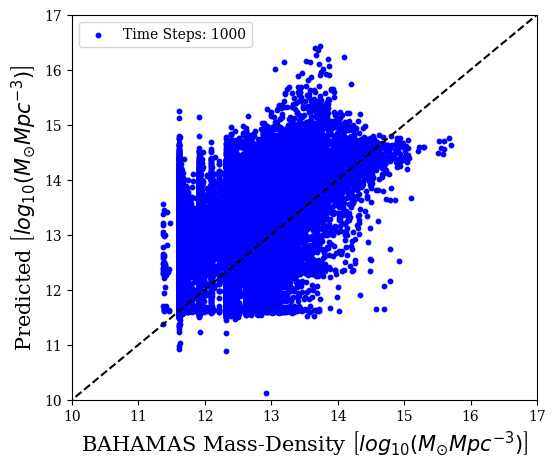

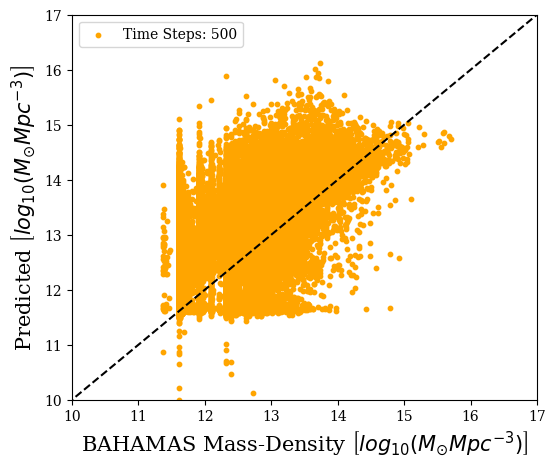

In [82]:
nonzero_pix = data_true_cube > -5

rho_true_flat = np.log10(rho[nonzero_pix])
rho_samp_flat = np.log10(np.array([rho_samp[i][nonzero_pix] for i in range(rho_samp.shape[0])]))

one_one = np.linspace(-5, 20, 100)

x_plot, y_plot = rho_true_flat, rho_samp_flat

colors = np.array(['red', 'green', 'blue', 'orange'])

#for i in range(rho_samp.shape[0]):
for i in range(4):

    fig, axs = plt.subplots(1, 1, figsize=(6, 5), gridspec_kw={'wspace': 0.35})

    axs.scatter(x_plot, y_plot[i], c=colors[i], label=f'Time Steps: {inf_steps[i]}', s=10)

    axs.plot(one_one, one_one, c='k', linestyle='--')
    axs.set_xlabel(r'BAHAMAS Mass-Density $\left[ log_{10}(M_{\odot} Mpc^{-3}) \right]$', fontsize = 15)
    axs.set_ylabel(r'Predicted $\left[ log_{10}(M_{\odot} Mpc^{-3}) \right]$', fontsize = 15)
    lims = np.concatenate([x_plot, y_plot.flatten()])
    axs.set_xlim(10, 17)
    axs.set_ylim(10, 17)
    axs.legend()

    plt.show()

### Function for calculating cluster mass from voxelized cube

In [83]:
def cube_to_mass_msun(cube_norm, metadata):
    """
    cube_norm: (Z,Y,X) normalized/log-standardized cube from your dataset or samples
    metadata: HDF5 attrs dict from preload_hdf5_to_memory(... )["metadata"]

    returns:
        enclosed mass inside the cube in Msun
    """
    cube_mean = float(metadata["cube_log10_mean"])
    cube_std = float(metadata["cube_log10_std"])
    floor_value = float(metadata["floor_value"])
    fov_mpc = float(metadata["map_fov_mpc"])
    N = int(metadata["cube_resolution"])

    # invert normalization
    rho = np.zeros_like(cube_norm, dtype=np.float64)
    mask = cube_norm > floor_value + 1e-6
    rho[mask] = 10.0 ** (cube_norm[mask] * cube_std + cube_mean)  # Msun / Mpc^3

    # voxel volume
    voxel_size = (2.0 * fov_mpc) / N
    voxel_vol = voxel_size ** 3  # Mpc^3

    mass = np.sum(rho) * voxel_vol
    return mass

### Calculate cluster masses

In [84]:
metadata = data_dict["metadata"]

true_mass = np.log10(cube_to_mass_msun(data_true_cube, metadata))
sample_masses = np.log10(np.array([cube_to_mass_msun(data_sampled_cubes[i, :, :, :], metadata) for i in range(data_sampled_cubes.shape[0])]))

### Cluster mass histogram

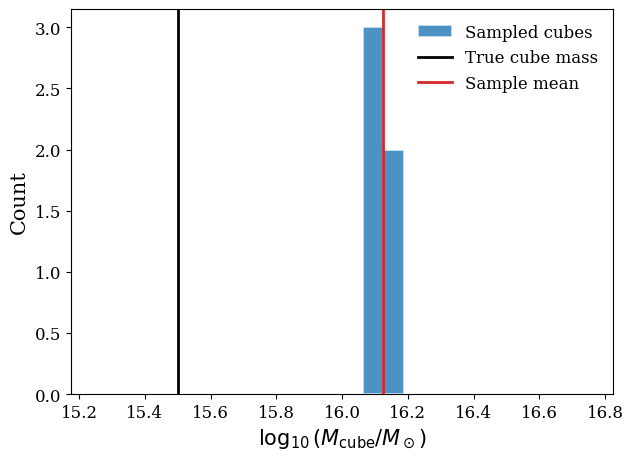

In [85]:
fig, ax = plt.subplots(figsize=(7, 5))

bins = np.linspace(15.25, 16.75, 25)

ax.hist(
    sample_masses,
    bins=bins,
    alpha=0.8,
    edgecolor='white',
    linewidth=1.2,
    label='Sampled cubes'
)

ax.axvline(
    true_mass,
    color='black',
    linestyle='-',
    linewidth=2,
    label='True cube mass'
)

ax.axvline(
    np.mean(sample_masses),
    color='tab:red',
    linestyle='-',
    linewidth=2,
    label='Sample mean'
)

ax.set_xlabel(r'$\log_{10}(M_{\rm cube}/M_\odot)$', fontsize=15)
ax.set_ylabel('Count', fontsize=15)

ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, frameon=False)

### Import samples for many examples

In [91]:
sample_base_path = '/projects/mccleary_group/habjan.e/TNG/Data/conditional_diffusion_data/cd_examples/'
sample_path = sample_base_path + f'sampled_cubes_100random_fixedseed_0{suffix}.npz'
data = np.load(sample_path)
data_im, data_true_cube, data_sampled_cubes, seed = data['conditioning_images'], data['true_cubes'], data['sampled_cubes'], data['fixed_seed']

seed

array(0, dtype=int32)

### Make arrays of cluster enclosed mass

In [94]:
metadata = data_dict["metadata"]

true_masses = np.log10(np.array([cube_to_mass_msun(data_true_cube[i, :, :, :], metadata) for i in range(data_true_cube.shape[0])]))
sample_masses = np.log10(np.array([cube_to_mass_msun(data_sampled_cubes[i, :, :, :], metadata) for i in range(data_sampled_cubes.shape[0])]))

### Plot direct comparison of cube masses

Text(0, 0.5, 'Sampled Cube $[\\log_{10}(M_{\\rm cube}/M_\\odot)]$')

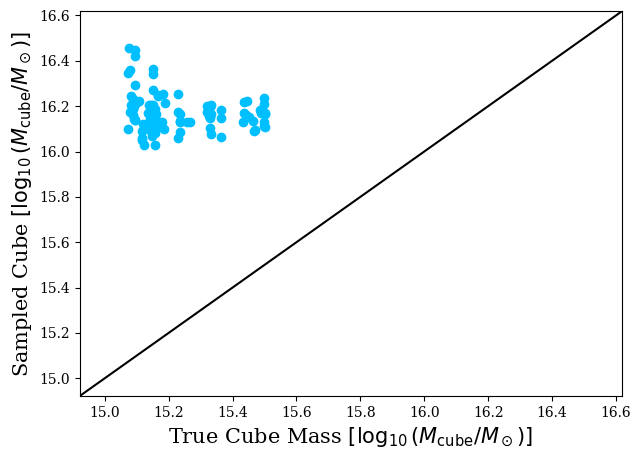

In [105]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(true_masses, sample_masses, c='deepskyblue')

concat_mass = np.concatenate([true_masses, sample_masses])
min_m, max_m = np.min(concat_mass)*0.99, np.max(concat_mass)*1.01

ax.set_xlim(min_m, max_m)
ax.set_ylim(min_m, max_m)


one_one = np.linspace(min_m * 0.1, max_m * 10, 25)
ax.plot(one_one, one_one, c='k')

ax.set_xlabel(r'True Cube Mass $[\log_{10}(M_{\rm cube}/M_\odot)]$', fontsize=15)
ax.set_ylabel(r'Sampled Cube $[\log_{10}(M_{\rm cube}/M_\odot)]$', fontsize=15)